In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.svm import SVC
from sklearn.metrics import classification_report, accuracy_score

# 1. Load the data
df = pd.read_csv('bquxjob_53df59f6_19d7dee5620.csv')

# 2. Filter out "Post-surgical/Unchanged" and "Unclear" classes
df = df[~df['ct_classification'].isin(['Post-surgical/Unchanged', 'Unclear'])]

# 3. Drop irrelevant columns
cols_to_drop = ['subject_id', 'hadm_id', 'stay_id', 'ct_order_time', 'inr']
df = df.drop(columns=[c for c in cols_to_drop if c in df.columns])

# 4. Separate features (X) and target (y)
X = df.drop(columns=['ct_classification'])
y = df['ct_classification']

# 5. Identify numeric and categorical columns
numeric_features = X.select_dtypes(include=['int64', 'float64']).columns
categorical_features = X.select_dtypes(include=['object']).columns

# 6. Define preprocessing pipelines
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features)
    ])

# 7. Define Standard SVM model
model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', SVC(kernel='rbf', random_state=42))
])

# 8. Split into 80% train and 20% test subsets, stratifying by target class
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42, stratify=y)

# 9. Train and evaluate
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

Accuracy: 0.8451025056947609

Classification Report:
               precision    recall  f1-score   support

    Negative       0.87      0.94      0.90       677
    Positive       0.71      0.54      0.62       201

    accuracy                           0.85       878
   macro avg       0.79      0.74      0.76       878
weighted avg       0.84      0.85      0.84       878



In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder, LabelEncoder
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier

# Load data
df = pd.read_csv('bquxjob_53df59f6_19d7dee5620.csv')
df = df[~df['ct_classification'].isin(['Post-surgical/Unchanged', 'Unclear'])]
cols_to_drop = ['subject_id', 'hadm_id', 'stay_id', 'ct_order_time', 'inr']
df = df.drop(columns=[c for c in cols_to_drop if c in df.columns])

X = df.drop(columns=['ct_classification'])
y_str = df['ct_classification']

le = LabelEncoder()
y = le.fit_transform(y_str)

numeric_features = X.select_dtypes(include=['int64', 'float64']).columns
categorical_features = X.select_dtypes(include=['object']).columns

preprocessor = ColumnTransformer(
    transformers=[
        ('num', Pipeline([('imputer', SimpleImputer(strategy='median')), ('scaler', StandardScaler())]), numeric_features),
        ('cat', Pipeline([('imputer', SimpleImputer(strategy='most_frequent')), ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))]), categorical_features)
    ])

models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'Random Forest': RandomForestClassifier(random_state=42),
    'Gradient Boosting': GradientBoostingClassifier(random_state=42),
    'SVM (RBF)': SVC(kernel='rbf', probability=True, random_state=42),
    'KNN': KNeighborsClassifier()
}

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42, stratify=y)

results = []

for name, clf in models.items():
    model = Pipeline(steps=[('preprocessor', preprocessor), ('classifier', clf)])
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    rep = classification_report(y_test, y_pred, target_names=le.classes_, output_dict=True)

    results.append({
        'Model': name,
        'Class': 'Negative',
        'Precision': rep['Negative']['precision'],
        'Recall': rep['Negative']['recall'],
        'F1-Score': rep['Negative']['f1-score'],
        'Support': rep['Negative']['support']
    })
    results.append({
        'Model': name,
        'Class': 'Positive',
        'Precision': rep['Positive']['precision'],
        'Recall': rep['Positive']['recall'],
        'F1-Score': rep['Positive']['f1-score'],
        'Support': rep['Positive']['support']
    })

res_df = pd.DataFrame(results)
print(res_df.to_string(index=False))
res_df.to_csv('per_class_benchmarks.csv', index=False)

              Model    Class  Precision   Recall  F1-Score  Support
Logistic Regression Negative   0.873961 0.932053  0.902073    677.0
Logistic Regression Positive   0.705128 0.547264  0.616246    201.0
      Random Forest Negative   0.869565 0.945347  0.905874    677.0
      Random Forest Positive   0.739437 0.522388  0.612245    201.0
  Gradient Boosting Negative   0.876045 0.929099  0.901792    677.0
  Gradient Boosting Positive   0.700000 0.557214  0.620499    201.0
          SVM (RBF) Negative   0.873103 0.935007  0.902996    677.0
          SVM (RBF) Positive   0.712418 0.542289  0.615819    201.0
                KNN Negative   0.834711 0.895126  0.863863    677.0
                KNN Positive   0.532895 0.402985  0.458924    201.0


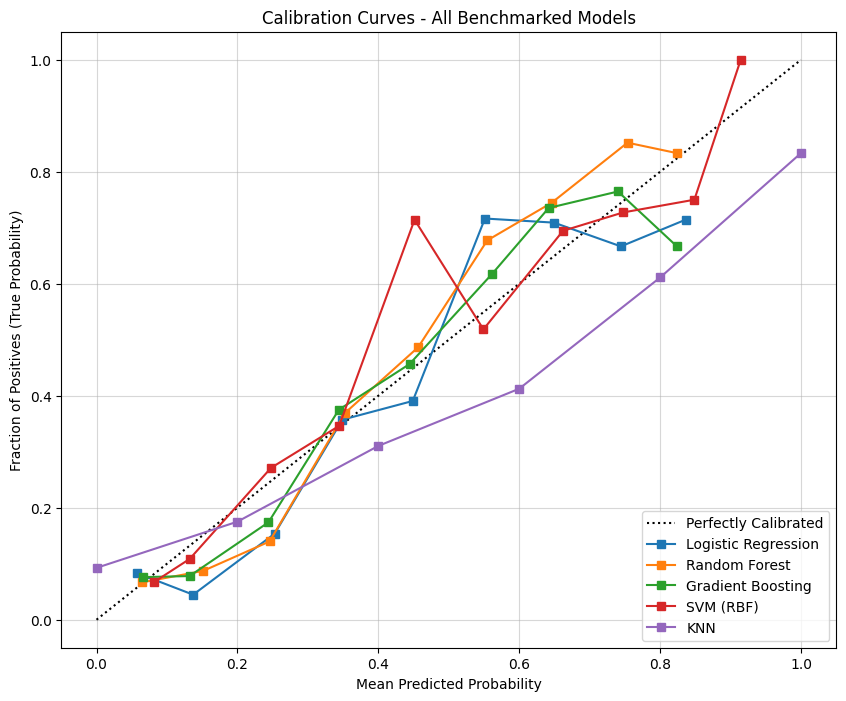

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder, LabelEncoder
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.calibration import calibration_curve

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier

# 1. Load data and filter to binary classification
df = pd.read_csv('bquxjob_53df59f6_19d7dee5620.csv')
df = df[~df['ct_classification'].isin(['Post-surgical/Unchanged', 'Unclear'])]
cols_to_drop = ['subject_id', 'hadm_id', 'stay_id', 'ct_order_time', 'inr']
df = df.drop(columns=[c for c in cols_to_drop if c in df.columns])

# 2. Extract features and target
X = df.drop(columns=['ct_classification'])
y_str = df['ct_classification']

# 3. Encode classes
le = LabelEncoder()
y = le.fit_transform(y_str)
pos_class_idx = le.transform(['Positive'])[0]

# 4. Set up preprocessing
numeric_features = X.select_dtypes(include=['int64', 'float64']).columns
categorical_features = X.select_dtypes(include=['object']).columns

preprocessor = ColumnTransformer(
    transformers=[
        ('num', Pipeline([('imputer', SimpleImputer(strategy='median')), ('scaler', StandardScaler())]), numeric_features),
        ('cat', Pipeline([('imputer', SimpleImputer(strategy='most_frequent')), ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))]), categorical_features)
    ])

# 5. Define all models
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'Random Forest': RandomForestClassifier(random_state=42),
    'Gradient Boosting': GradientBoostingClassifier(random_state=42),
    'SVM (RBF)': SVC(kernel='rbf', probability=True, random_state=42), # Must set probability=True
    'KNN': KNeighborsClassifier()
}

# 6. Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42, stratify=y)

# 7. Initialize Plot
plt.figure(figsize=(10, 8))
plt.plot([0, 1], [0, 1], "k:", label="Perfectly Calibrated")

# 8. Train each model, calculate probabilities, and add to plot
for name, clf in models.items():
    model = Pipeline(steps=[('preprocessor', preprocessor), ('classifier', clf)])
    model.fit(X_train, y_train)

    # Predict probabilities for the positive class
    y_prob = model.predict_proba(X_test)[:, pos_class_idx]

    prob_true, prob_pred = calibration_curve(y_test == pos_class_idx, y_prob, n_bins=10)

    plt.plot(prob_pred, prob_true, "s-", label=f"{name}")

# 9. Format and save
plt.ylabel("Fraction of Positives (True Probability)")
plt.xlabel("Mean Predicted Probability")
plt.title("Calibration Curves - All Benchmarked Models")
plt.legend(loc="lower right")
plt.grid(True, alpha=0.5)
plt.savefig('calibration_curve_all_models.png', bbox_inches='tight')

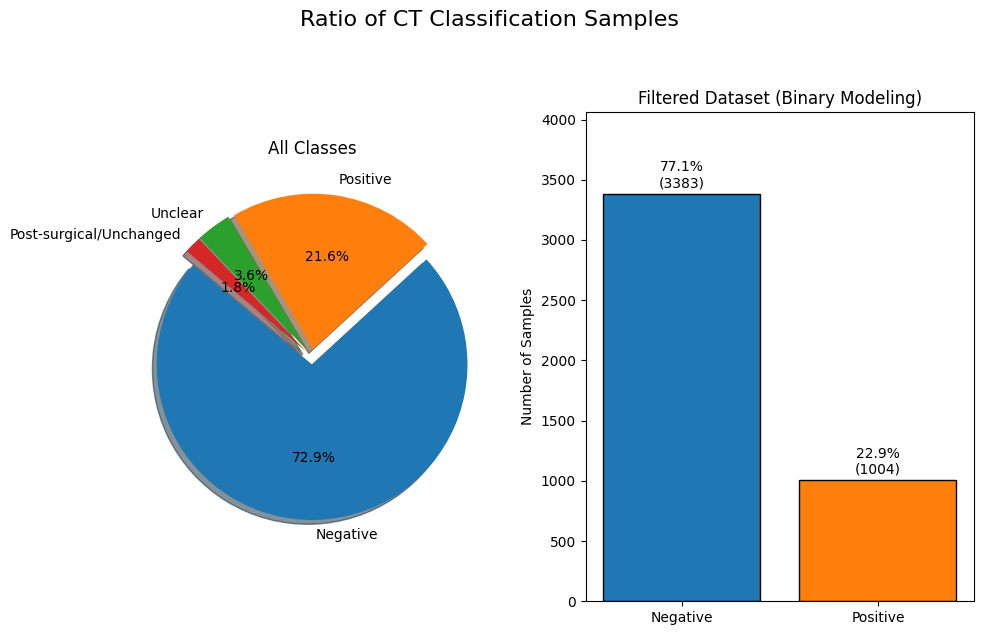

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# 1. Load data
df = pd.read_csv('bquxjob_53df59f6_19d7dee5620.csv')

# 2. Calculate counts and ratios for ALL classes
class_counts = df['ct_classification'].value_counts()
class_ratios = class_counts / class_counts.sum() * 100

# 3. Initialize Plotting
plt.figure(figsize=(10, 6))

# Subplot A: Pie chart for overall visual distribution
plt.subplot(1, 2, 1)
plt.pie(class_counts, labels=class_counts.index, autopct='%1.1f%%', startangle=140,
        colors=['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728'],
        explode=[0.05]*len(class_counts), shadow=True)
plt.title('All Classes', fontsize=12)

# Subplot B: Bar chart focusing on the binary problem (Filtered)
df_filtered = df[~df['ct_classification'].isin(['Post-surgical/Unchanged', 'Unclear'])]
filtered_counts = df_filtered['ct_classification'].value_counts()

plt.subplot(1, 2, 2)
bars = plt.bar(filtered_counts.index, filtered_counts.values, color=['#1f77b4', '#ff7f0e'], edgecolor='black')
plt.title('Filtered Dataset (Binary Modeling)', fontsize=12)
plt.ylabel('Number of Samples')

# Add percentage and count labels on top of the bars
for bar in bars:
    height = bar.get_height()
    percentage = (height / filtered_counts.sum()) * 100
    plt.text(bar.get_x() + bar.get_width()/2., height + 30,
             f'{percentage:.1f}%\n({int(height)})',
             ha='center', va='bottom', fontsize=10)

plt.ylim(0, max(filtered_counts.values) * 1.2)
plt.suptitle('Ratio of CT Classification Samples', fontsize=16, y=1.05)
plt.tight_layout()

# Save the resulting figure
plt.savefig('class_ratio_plot.png', bbox_inches='tight')